In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
# import sys
# sys.path.append('/content/drive/MyDrive/Colab Notebooks/LEVEL 1/torch')
# from multiclass_functions2 import * # my module import
# import torch
# from torch import nn, optim
# from torchvision import datasets, transforms
# from torch.utils.data import Dataset, DataLoader, random_split
# import numpy as np
# import matplotlib.pyplot as plt
# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# print(DEVICE)

Mounted at /content/drive
cuda


In [ ]:
#로컬에서 확장 colab용 환경설정
# from google.colab import drive
# drive.mount('/content/drive')
# import sys
# sys.path.append('/content/drive/MyDrive/Colab Notebooks/LEVEL 1/torch')
import os
os.makedirs("/content/results", exist_ok=True)
os.makedirs("/content/data", exist_ok=True)
print(os.getcwd())
os.chdir("/content/results") #colab클라우드 런타임에 가상폴더 만들고 이동 

print(os.getcwd())
import torch
#multiclass_functions2는 multiclass_functions1과 다르게 val data도 사용하는 모듈
from multiclass_functions2 import * # my module import # * 은 all을 의미, 따로 로컬 colab에서 파일 우클릭으로 런타임에 업로드해야함
import torch
from torch import nn, optim
from torch.optim.lr_scheduler import StepLR
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

/content/results
/content/results
cuda


In [14]:
BATCH_SIZE = 64
LR = 2e-3
LR_STEP = 3
LR_GAMMA = 0.9
LAMBDA = 1e-6
EPOCH = 15
criterion = nn.CrossEntropyLoss()
# new_model_train = False
new_model_train = True
model_type = "CNN_deep"
dataset = "STL10"
#save_model_path = f'/content/drive/MyDrive/Colab Notebooks/results/{model_type}_{dataset}.pt'
#save_history_path = f'/content/drive/MyDrive/Colab Notebooks/results/{model_type}_history_{dataset}.pt'
save_model_path = f'/content/results/{model_type}_{dataset}.pt'
save_history_path = f'/content/results/{model_type}_history_{dataset}.pt'

In [5]:
transform_train = transforms.Compose([
    transforms.RandomAffine(degrees=(0,10),translate=(0.1,0.2),scale=(0.5,1.2)),
    transforms.ToTensor()])

transform_test = transforms.Compose([
    transforms.ToTensor()])

In [6]:
class SubsetWithTransform(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        self.classes = subset.dataset.classes

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

In [7]:
#train_DS = datasets.STL10(root = '/content/drive/MyDrive/Colab Notebooks/data', split="train", download=True)
train_DS = datasets.STL10(root = '/content/data', split="train", download=True) # split옵션으로 train, test데이터 나눌수있다
NoT = int(0.8 * len(train_DS))
NoV = len(train_DS) - NoT
train_DS, val_DS = random_split(train_DS, [NoT, NoV])

train_DS = SubsetWithTransform(train_DS, transform=transform_train) # transform을 train과 val 다르게 주기 위함
val_DS = SubsetWithTransform(val_DS, transform=transform_test) # transform을 train과 val 다르게 주기 위함
#test_DS = datasets.STL10(root = '/content/drive/MyDrive/Colab Notebooks/data', split="test", download=True, transform=transform_test)
test_DS = datasets.STL10(root = '/content/data', split="test", download=True, transform=transform_test)

train_DL = DataLoader(train_DS, batch_size = BATCH_SIZE, shuffle = True)
val_DL = DataLoader(val_DS, batch_size = BATCH_SIZE, shuffle = True)
test_DL = DataLoader(test_DS, batch_size = BATCH_SIZE, shuffle = True)

100%|██████████| 2.64G/2.64G [04:10<00:00, 10.5MB/s]  


In [8]:
print(len(train_DS))
print(len(val_DS))
print(len(test_DS))

4000
1000
8000


### stl10은 cifar-10에 비해 해상도가 크고 데이터는 적다.
- torch.Size([64, 3, 96, 96])

['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
torch.Size([64, 3, 96, 96])
deer


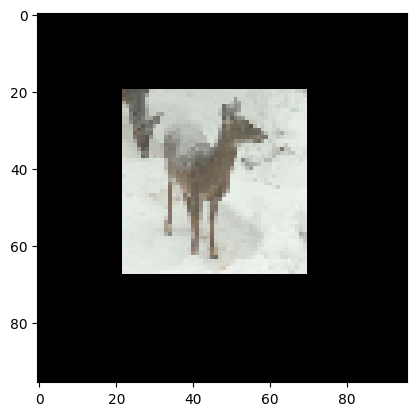

In [ ]:
print(test_DS.classes)
x_batch, y_batch = next(iter(train_DL))
print(x_batch.shape)
plt.imshow(x_batch[0].permute(1,2,0)) #plt로 그리기위해 tensortype의 채널이 맨뒤에 가도록 위치 바꿈
print(test_DS.classes[y_batch[0]])

torch.Size([64, 3, 96, 96])
bird


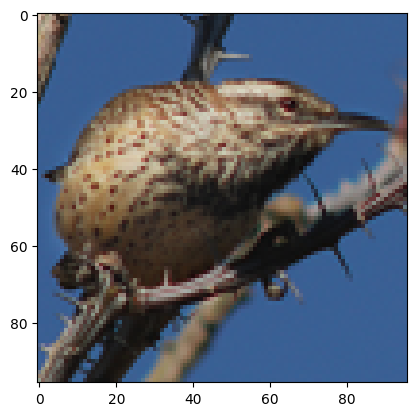

In [10]:
x_batch, y_batch = next(iter(val_DL))
print(x_batch.shape)
plt.imshow(x_batch[0].permute(1,2,0))
print(test_DS.classes[y_batch[0]])

torch.Size([64, 3, 96, 96])
monkey


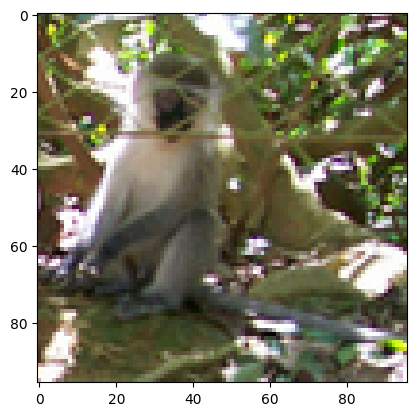

In [11]:
x_batch, y_batch = next(iter(test_DL))
print(x_batch.shape)
plt.imshow(x_batch[0].permute(1,2,0))
print(test_DS.classes[y_batch[0]])

In [12]:
class CNN_deep(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block1 = nn.Sequential(nn.Conv2d(3,32,3,padding=1, bias=False),
                                         nn.BatchNorm2d(32),
                                         nn.ReLU(),
                                         nn.Conv2d(32,32,3,padding=1, bias=False),
                                         nn.BatchNorm2d(32),
                                         nn.ReLU())
        self.Maxpool1 = nn.MaxPool2d(2)
        self.conv_block2 = nn.Sequential(nn.Conv2d(32,64,3,padding=1, bias=False),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU(),
                                         nn.Conv2d(64,64,3,padding=1, bias=False),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU(),
                                         nn.Conv2d(64,64,3,padding=1, bias=False),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU())
        self.Maxpool2 = nn.MaxPool2d(2)

        self.conv_block3 = nn.Sequential(nn.Conv2d(64,128,3,padding=1, bias=False),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU(),
                                         nn.Conv2d(128,128,3,padding=1, bias=False),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU(),
                                         nn.Conv2d(128,128,3,padding=1, bias=False),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU())
        self.Maxpool3 = nn.MaxPool2d(2)
        self.classifier = nn.Sequential(nn.Linear(128*12*12,512),
                                        nn.ReLU(),
                                        nn.Linear(512,10))

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.Maxpool1(x)
        x = self.conv_block2(x)
        x = self.Maxpool2(x)
        x = self.conv_block3(x)
        x = self.Maxpool3(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x

In [ ]:
model = globals()[model_type]().to(DEVICE) #지금 런타임 장치인 DEVICE에 올라간 모델의 층 layer에 대한 값들을 dic으로 반환
print(model)

x_batch, _ = next(iter(train_DL))
print(x_batch.shape)

# model.eval()
# with torch.no_grad():
#     print(model(x_batch.to(DEVICE)).shape)

CNN_deep(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (Maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1

### StepLR은 learning rate를 step decay로 조절한다.(lr에 gamma곱하여 조절)
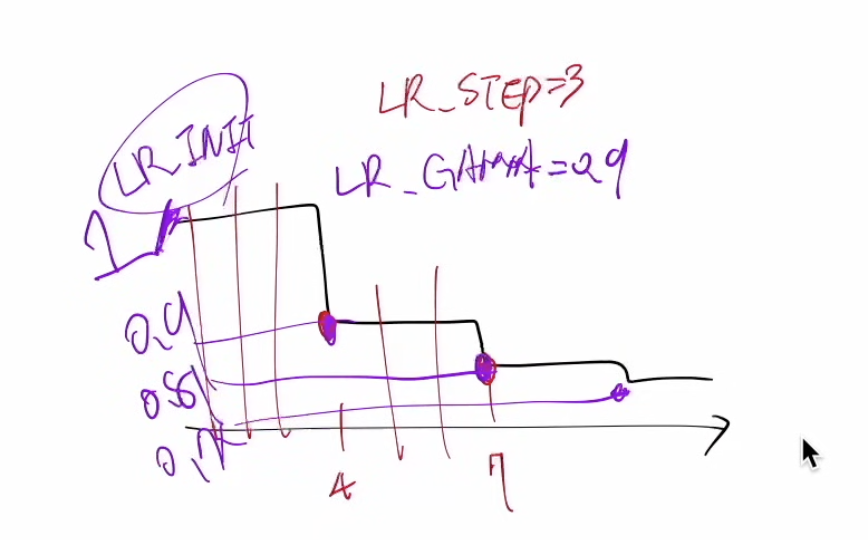
- LR_INIT(optimizer코드에 포함되어있다.)에 LR_GAMMA를 곱하여 LR을 LR_STEP(한 epoch당 한 step으로 카운팅하게 multiclass_functions2 모듈에 train코드 짜놓음)다음부터 줄임

In [ ]:
if new_model_train:
    params = [p for p in model.parameters() if p.requires_grad] # for transfer learning
    optimizer = optim.Adam(params, lr = LR, weight_decay=LAMBDA)
    scheduler = StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA) #learning rate 조절해주는 scheduler추가, step_size(LR_STEP다음번째부터  lr에 gamma를 곱하여 lr갱신함

    Train(model, train_DL, val_DL, criterion, optimizer, scheduler,
          EPOCH, BATCH_SIZE, save_model_path, save_history_path)

Epoch: 1, current_LR = 0.002


train loss: 5.32036, val loss: 2.44384 
train acc: 11.0 %, val acc: 13.3 %, time: 9 s
--------------------
Epoch: 2, current_LR = 0.002


train loss: 2.30909, val loss: 2.21375 
train acc: 13.9 %, val acc: 21.3 %, time: 7 s
--------------------
Epoch: 3, current_LR = 0.002


train loss: 2.11732, val loss: 2.31541 
train acc: 20.0 %, val acc: 17.6 %, time: 7 s
--------------------
Epoch: 4, current_LR = 0.0018000000000000002


train loss: 2.02383, val loss: 1.87520 
train acc: 22.7 %, val acc: 25.3 %, time: 7 s
--------------------
Epoch: 5, current_LR = 0.0018000000000000002


...

train loss: 1.66563, val loss: 2.47219 
train acc: 34.0 %, val acc: 23.6 %, time: 7 s
--------------------
Epoch: 12, current_LR = 0.001458


train loss: 1.64319, val loss: 2.17035 
train acc: 34.8 %, val acc: 26.5 %, time: 7 s
--------------------
Epoch: 13, current_LR = 0.0013122000000000001


train loss: 1.62760, val loss: 1.64163 
train acc: 35.9 %, val acc: 38.6 %, time: 7 s
--------------------
Epoch: 14, current_LR = 0.0013122000000000001


train loss: 1.58440, val loss: 2.38250 
train acc: 38.2 %, val acc: 27.4 %, time: 7 s
--------------------
Epoch: 15, current_LR = 0.0013122000000000001


train loss: 1.56271, val loss: 1.52520 
train acc: 38.7 %, val acc: 41.8 %, time: 7 s
--------------------


### 모델파라미터 뿐만 아니라 다른 epoch, optim, scheduler등도 save에 저장
- 왜? 저장할까?: 모델 save후 재학습(이전학습 이어 시키기) 시키기 위해서는 loss와 파라미터 가지고는 안된다. optimizer와 scheduler도 같이 가지고있어야 save시점부터 같이 최적화와 스케쥴링을 통한 lr조절도 이어서 되기떄문에
- optim중에 Adam같은경우 누적값의 gradient를 사용하여 현재 방향을 설정할떄 사용하기떄문에 누적값이 필요함, 따라서 save시 지금까지 학습된 결과의 누적 gradient가 담긴 optim도 같이 저장해야함(현재 gradient의 방향을 정해야함, 저장안하면 이전까지 학습된 graident의 방향은 무시하고 다시 정하게 되는것, 온전한 재학습 불가)
- 추가로 transfer learning해서 finetuning할거면 새로운 데이터로 학습시키는거기때문에 모델의 파라미터만 재사용(새 데이터랑 새 task푸는것)

In [ ]:
loaded = torch.load(save_model_path, map_location=DEVICE, weights_only=False)
load_model = loaded["model"]
ep = loaded["ep"]

optimizer = loaded["optimizer"]
scheduler = loaded["scheduler"]

loaded = torch.load(save_history_path, map_location=DEVICE, weights_only=False)
loss_history = loaded["loss_history"]
acc_history = loaded["acc_history"]

print(ep)
print(optimizer)
print(scheduler.step_size)
print(scheduler.gamma)

15
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.002
    lr: 0.0013122000000000001
    maximize: False
    weight_decay: 1e-06
)
3
0.9


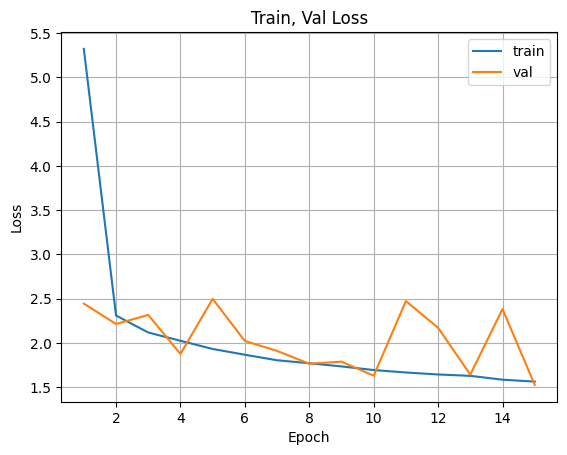

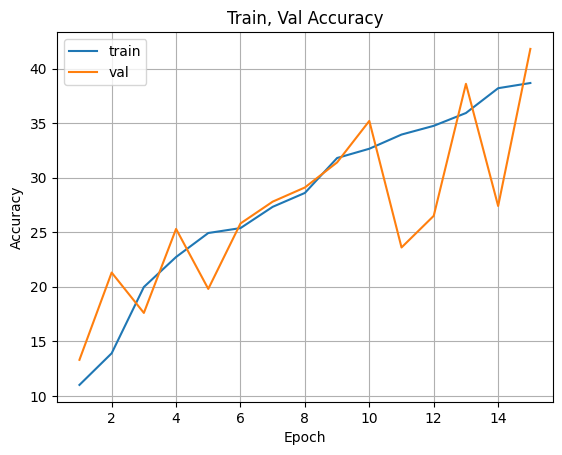

In [17]:
plt.figure()
plt.plot(range(1,EPOCH+1), loss_history["train"], label="train")
plt.plot(range(1,EPOCH+1), loss_history["val"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train, Val Loss")
plt.legend()
plt.grid()

plt.figure()
plt.plot(range(1,EPOCH+1), acc_history["train"], label="train")
plt.plot(range(1,EPOCH+1), acc_history["val"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train, Val Accuracy")
plt.legend()
plt.grid()

### 추후 모델의 성능을 높여보자(과제)

In [18]:
Test(load_model, test_DL, criterion)
print(count_params(load_model))


Test loss: 1.529
Test accuracy: 3223/8000 (40.3 %)
9914986


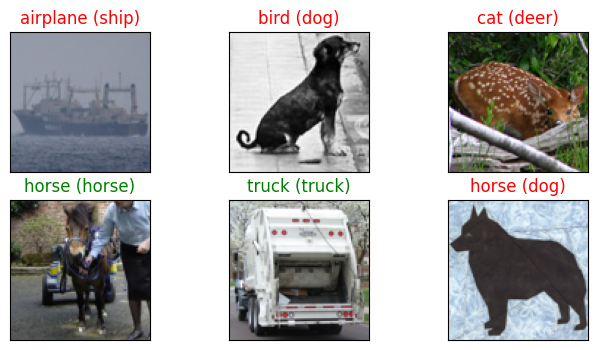

In [21]:
Test_plot(load_model,test_DL)

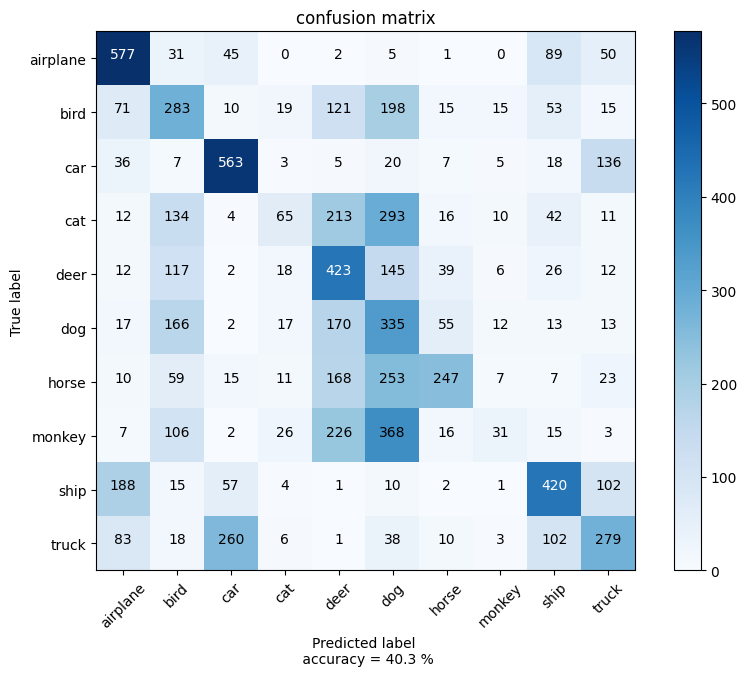

In [20]:
confusion = get_conf(load_model, test_DL)
plot_confusion_matrix(confusion, test_DS.classes)
plt.xticks(rotation=45);